In [65]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Load dataset
df = pd.read_csv('updated_customer_data.csv')

df.head()

,age,income,purchase_amount,promotion_usage,satisfaction_score
0,27,40682,18249,0,6
1,29,15317,4557,1,6
2,37,38849,11822,0,6
3,30,11568,4098,0,7
4,31,46952,19685,1,5


In [66]:
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   age                 100000 non-null  int64
 1   income              100000 non-null  int64
 2   purchase_amount     100000 non-null  int64
 3   promotion_usage     100000 non-null  int64
 4   satisfaction_score  100000 non-null  int64
dtypes: int64(5)
memory usage: 3.8 MB
None
                 age         income  purchase_amount  promotion_usage  \
count  100000.000000  100000.000000    100000.000000    100000.000000   
mean       30.003260   27516.269880      9634.790840         0.300800   
std         4.480535   12996.782587      4799.339449         0.458608   
min        12.000000    5000.000000      1118.000000         0.000000   
25%        27.000000   16271.750000      5583.000000         0.000000   
50%        30.000000   27584.500000      9452.000000         0.000000   
75%        3

In [ ]:
X = df.drop('satisfaction_score', axis=1)
y = df['satisfaction_score']

feature_names = X.columns

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Feature Importance
importance = model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance)

           Feature  Importance
1           income    0.434322
2  purchase_amount    0.430298
0              age    0.110558
3  promotion_usage    0.024821


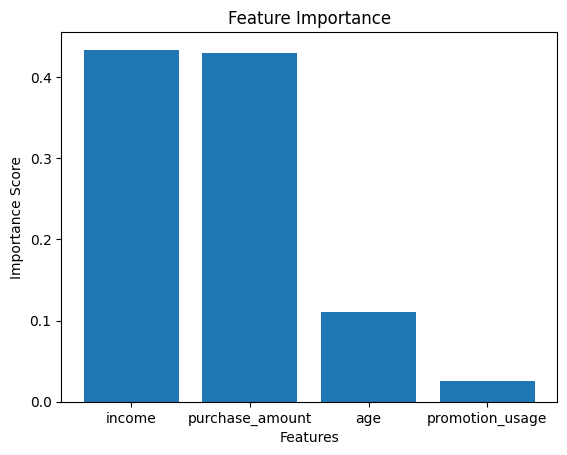

In [68]:
import matplotlib.pyplot as plt

plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

In [73]:
X = df.drop(['promotion_usage'], axis=1)
df = X

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report

y_pred = model.predict(X_test)

print("accuracy_score :", accuracy_score(y_test, y_pred))

print("precision :", precision_score(y_test, y_pred, average='weighted'))

print("recall :", recall_score(y_test, y_pred, average='weighted'))

print("f1_score :", f1_score(y_test, y_pred, average='weighted'))

print(classification_report(y_test, y_pred))

df.to_csv('updated_customer_data1.csv',index=False)

accuracy_score : 1.0
precision : 1.0
recall : 1.0
f1_score : 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00       110
           3       1.00      1.00      1.00      1133
           4       1.00      1.00      1.00      4736
           5       1.00      1.00      1.00      7745
           6       1.00      1.00      1.00      4927
           7       1.00      1.00      1.00      1215
           8       1.00      1.00      1.00       123
           9       1.00      1.00      1.00         7

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

